<a href="https://colab.research.google.com/github/bosro/3dPortfolio/blob/main/Anxiety_Prediction_Project_BCS_206.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Neccessary imports for the model and the dataset

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, log_loss, roc_auc_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # Use this for SMOTE in pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from graphviz import Digraph

Dataset Shape: (11000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                11000 non-null  int64  
 1   Gender                             11000 non-null  object 
 2   Occupation                         11000 non-null  object 
 3   Sleep Hours                        11000 non-null  float64
 4   Physical Activity (hrs/week)       11000 non-null  float64
 5   Caffeine Intake (mg/day)           11000 non-null  int64  
 6   Alcohol Consumption (drinks/week)  11000 non-null  int64  
 7   Smoking                            11000 non-null  object 
 8   Family History of Anxiety          11000 non-null  object 
 9   Stress Level (1-10)                11000 non-null  int64  
 10  Heart Rate (bpm)                   11000 non-null  int64  
 11  Breathing Rate (breaths/min

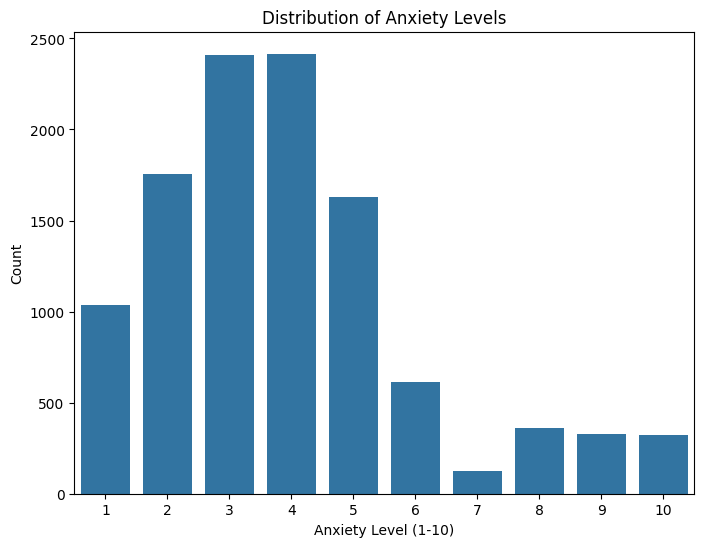

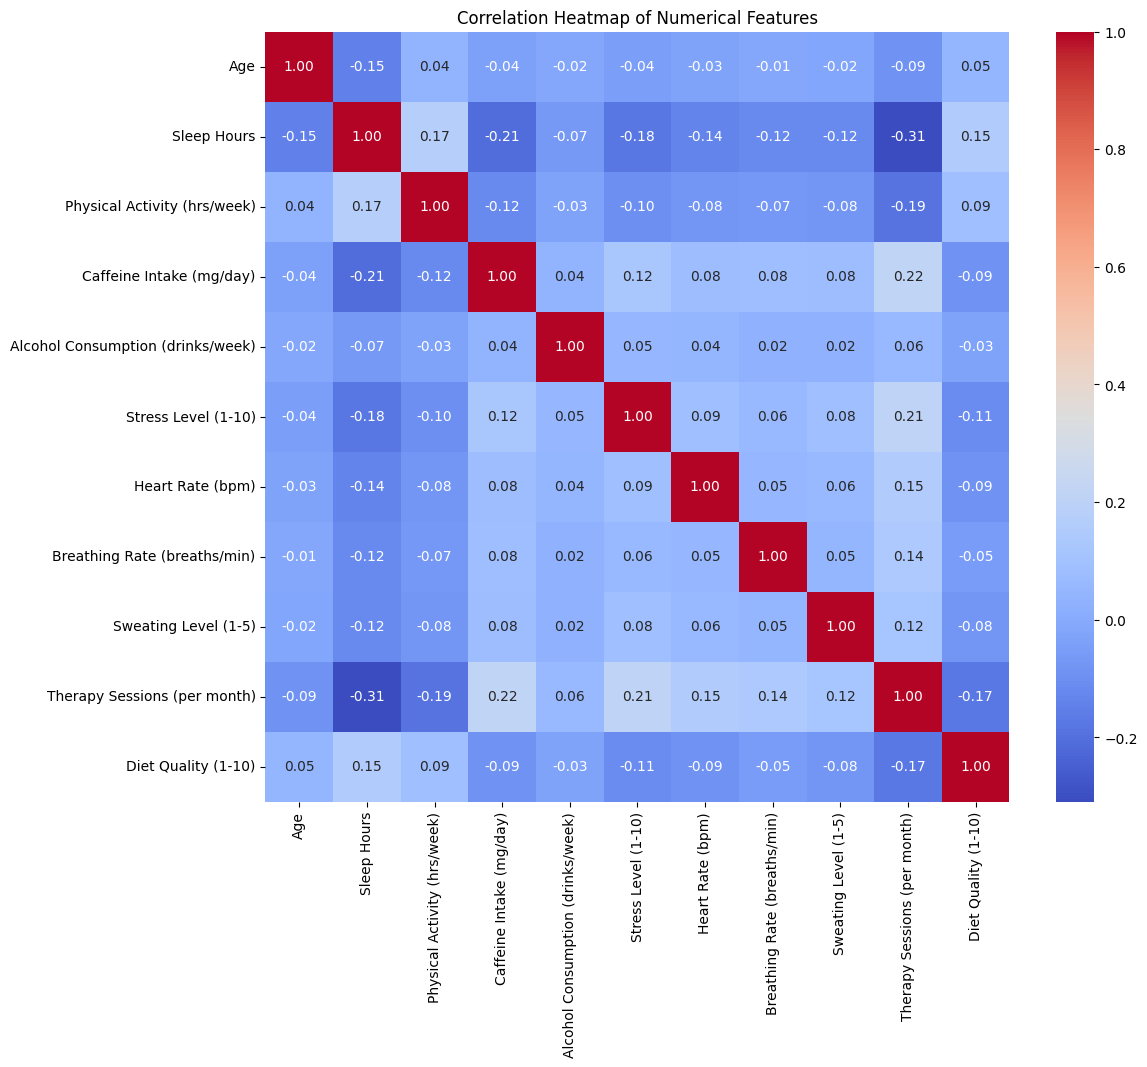

In [2]:
# Load the dataset
df = pd.read_csv('/content/enhanced_anxiety_dataset.csv')

# Convert any object columns that should be numeric (from dataset analysis)
cols_to_numeric = ['Alcohol Consumption (drinks/week)', 'Therapy Sessions (per month)', 'Sweating Level (1-5)']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # 'coerce' turns errors to NaN

# Drop rows with missing target (if any)
df = df.dropna(subset=['Anxiety Level (1-10)'])

# Convert target to integer for classification
df['Anxiety Level (1-10)'] = df['Anxiety Level (1-10)'].astype(int)

# Basic info
print("Dataset Shape:", df.shape)
print(df.info())  # Shows types and missing values
print(df.describe())  # Stats like mean, min, max

# Target distribution (to spot imbalance)
print(df['Anxiety Level (1-10)'].value_counts(normalize=True))
plt.figure(figsize=(8,6))
sns.countplot(x='Anxiety Level (1-10)', data=df)
plt.title('Distribution of Anxiety Levels')
plt.xlabel('Anxiety Level (1-10)')
plt.ylabel('Count')
plt.show()

# Correlation heatmap for numerical features
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('Anxiety Level (1-10)')
plt.figure(figsize=(12,10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

The above loaded dataset(enhanced_anxiety_dataset.csv) is appropriate as it includes features like sleep, caffeine, and stress, which are known predictors of anxiety. Which is relevant in the prediction model and can help support early interventions in students/professionals.

In [3]:
# Features (X) and target (y)
X = df.drop('Anxiety Level (1-10)', axis=1)
y = df['Anxiety Level (1-10)']

# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Preprocessor: Scale numbers, encode categories
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),  # Standardize (mean=0, std=1) for better ML
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)  # Convert categories to 0/1, drop one to avoid multicollinearity
    ])

# Pipeline: Preprocess + SMOTE + Model
model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),  # Oversample minority classes
    ('classifier', RandomForestClassifier(random_state=42))
])

# Split data: 80% train, 20% test (stratified to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train the model
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [4]:
# Hyperparameters to tune
param_grid = {
    'classifier__n_estimators': [100, 200],  # Number of trees
    'classifier__max_depth': [10, 20, None],  # Tree depth (None = unlimited)
    'classifier__min_samples_split': [2, 5],  # Min samples to split a node
    'classifier__class_weight': ['balanced', None]  # Weight classes for imbalance
}

# Grid search with 5-fold stratified cross-validation (CV)
cv = StratifiedKFold(n_splits=5)
grid_search = GridSearchCV(model, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)  # 'f1_macro' for multi-class balance
grid_search.fit(X_train, y_train)

# Best model and params
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score (macro):", grid_search.best_score_)

KeyboardInterrupt: 

Accuracy: 0.3359
Logarithmic Loss: 1.5170
Area Under Curve (AUC): 0.8443
Precision: 0.2889
Recall: 0.3025
F1 Score: 0.2931


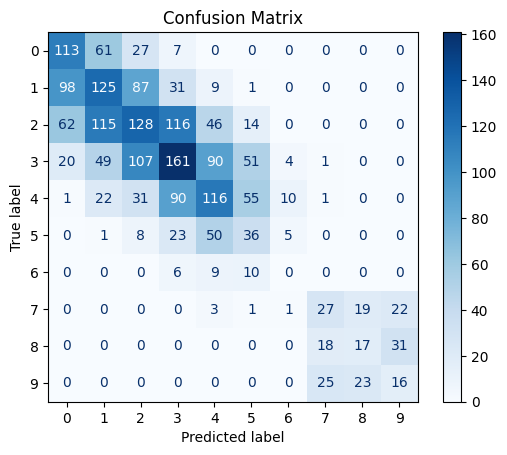

In [ ]:
# Predictions
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)  # Probabilities for log_loss and AUC

# Metrics (use 'macro' for unweighted multi-class average)
accuracy = accuracy_score(y_test, y_pred)
logloss = log_loss(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')  # One-vs-rest for multi-class
precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Logarithmic Loss: {logloss:.4f}")
print(f"Area Under Curve (AUC): {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Confusion Matrix visualization
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
dot = Digraph(comment='Proposed Anxiety Prediction Model')
dot.node('A', 'Data Input: enhanced_anxiety_dataset.csv (Features: Age, Sleep, etc.; Target: Anxiety Level)')
dot.node('B', 'Preprocessing: Scale Numerical (StandardScaler), Encode Categorical (OneHotEncoder)')
dot.node('C', 'Balance Classes: SMOTE for Imbalance')
dot.node('D', 'Classification: Random Forest (Tuned: n_estimators, max_depth, etc.)')
dot.node('E', 'Output: Predictions & Evaluation (Metrics: Acc, F1, Confusion Matrix)')
dot.edges(['AB', 'BC', 'CD', 'DE'])
dot.render('model_diagram', format='png', view=True)  # Saves as PNG

'model_diagram.png'

Accuracy: 0.3359
Logarithmic Loss: 1.5170
Area Under Curve (AUC): 0.8443
Precision: 0.2889
Recall: 0.3025
F1 Score: 0.2931


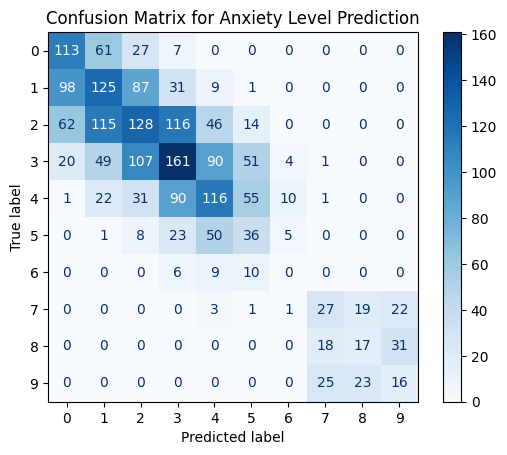

In [ ]:
# Make predictions on the test set
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)  # Needed for probabilistic metrics like Log Loss and AUC

# Compute all required metrics
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

accuracy = accuracy_score(y_test, y_pred)
logloss = log_loss(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro')

# Print results
print(f"Accuracy: {accuracy:.4f}")
print(f"Logarithmic Loss: {logloss:.4f}")
print(f"Area Under Curve (AUC): {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Anxiety Level Prediction')
plt.show()

In [ ]:
# Parameter tuning with GridSearchCV
param_grid = {
    'classifier__n_estimators': [100, 200, 300],  # More trees for better accuracy
    'classifier__max_depth': [10, 20, 30, None],  # Control tree depth
    'classifier__min_samples_split': [2, 5, 10],  # Prevent overfitting
    'classifier__class_weight': ['balanced', None]  # Handle imbalance
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(model, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1 Score:", grid_search.best_score_)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300}
Best Cross-Validation F1 Score: 0.3118274645187792
